In [9]:
import rdkit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from IPython.display import display

In [20]:
smiles = 'CC(C)OC(=O)C(C)NP(=O)(OCC1C(C(C(O1)N2C=CC(=O)NC2=O)(C)F)O)OC3=CC=CC=C3'

mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)

params = AllChem.ETKDGv3()
params.randomSeed = 2026
params.pruneRmsThresh = 0.3
params.numThreads = 0

conf_ids = list(AllChem.EmbedMultipleConfs(mol, numConfs=10, params=params))

opt_results = AllChem.MMFFOptimizeMoleculeConfs(
    mol, numThreads=0, mmffVariant='MMFF94'
 )

energy_records = []
for cid, (status, energy) in zip(conf_ids, opt_results):
    energy_records.append((cid, status, float(energy)))
pool = sorted(energy_records, key=lambda x: x[2])
top10 = pool[:10]
top10_ids = [cid for cid, _, _ in top10]
top10_energies = np.array([e for _, _, e in top10], dtype=float)
rel_e = top10_energies - top10_energies.min()

# 对齐到最低能构象，便于后续比较
for cid in top10_ids[1:]:
    AllChem.AlignMol(mol, mol, prbCid=cid, refCid=top10_ids[0])

print('最低能量 (kcal/mol):', float(top10_energies[0]))
print('最高能量 (kcal/mol):', float(top10_energies[-1]))
print('能量跨度 ΔE (kcal/mol):', float(top10_energies[-1] - top10_energies[0]))

最低能量 (kcal/mol): -107.48661203633316
最高能量 (kcal/mol): -84.02545324803143
能量跨度 ΔE (kcal/mol): 23.46115878830173


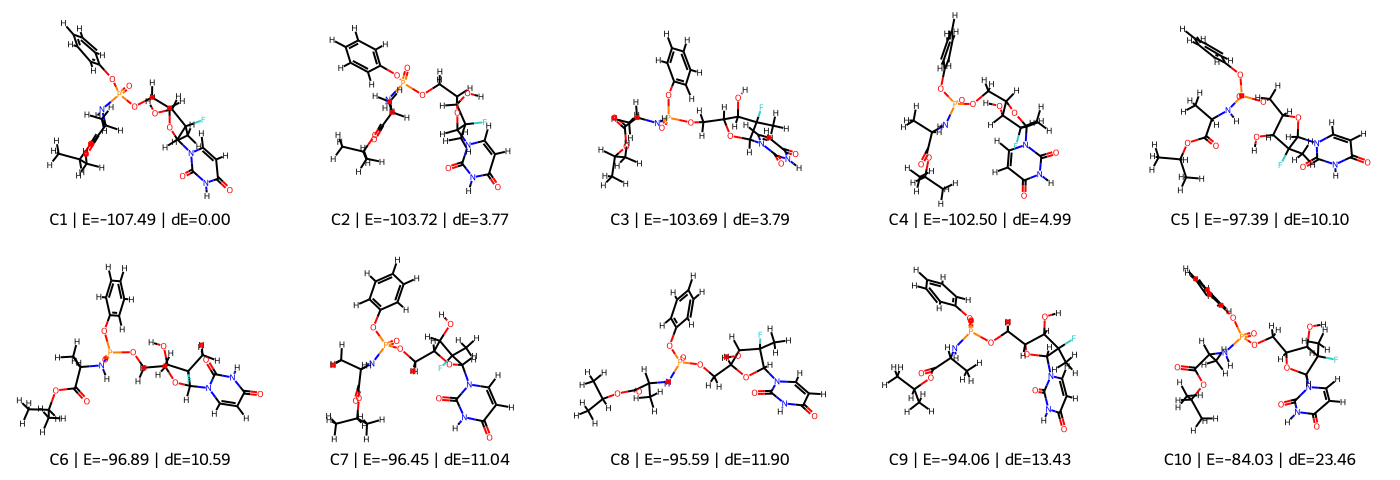

,rank,conf_id,energy_kcal_mol,deltaE_kcal_mol
0,1,0,-107.486612,0.000000
1,2,8,-103.719118,3.767494
2,3,6,-103.692754,3.793858
3,4,9,-102.495611,4.991001
4,5,3,-97.385243,10.101369
5,6,1,-96.894437,10.592175
6,7,7,-96.447890,11.038722
7,8,2,-95.588005,11.898608
8,9,4,-94.060190,13.426422
9,10,5,-84.025453,23.461159


/tmp/ipykernel_74680/3290314111.py:46: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_74680/3290314111.py:46: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_74680/3290314111.py:46: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_74680/3290314111.py:46: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_74680/3290314111.py:46: UserWarning: Glyph 35937 (\N{CJK UNIFIED IDEOGRAPH-8C61}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_74680/3290314111.py:46: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_74680/3290314111.py:46: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAP

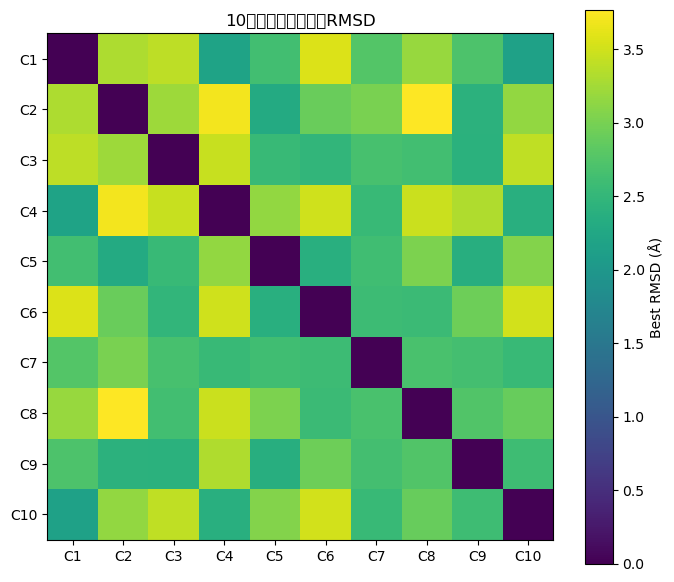

最大几何差异 (max RMSD): 3.769 Å
平均几何差异 (mean off-diagonal RMSD): 2.876 Å


In [ ]:
from rdkit.Chem import rdMolAlign

# 生成10个可视化分子（每个只保留一个构象）
viz_mols = []
legends = []
for i, cid in enumerate(top10_ids):
    m = Chem.Mol(mol)
    keep = m.GetConformer(cid).GetId()
    for conf in list(m.GetConformers()):
        if conf.GetId() != keep:
            m.RemoveConformer(conf.GetId())
    viz_mols.append(m)
    legends.append(f'C{i+1} | E={top10_energies[i]:.2f} | dE={rel_e[i]:.2f}')

img = Draw.MolsToGridImage(
    viz_mols,
    molsPerRow=5,
    subImgSize=(280, 240),
    legends=legends
 )
display(img)

# 用RMSD比较10个构象的几何差异
n = len(top10_ids)
rmsd = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        v = rdMolAlign.GetBestRMS(mol, mol, prbId=top10_ids[i], refId=top10_ids[j])
        rmsd[i, j] = v
        rmsd[j, i] = v

result_df = pd.DataFrame({
    'rank': np.arange(1, n + 1),
    'conf_id': top10_ids,
    'energy_kcal_mol': top10_energies,
    'deltaE_kcal_mol': rel_e
})
display(result_df)

plt.figure(figsize=(7, 6))
im = plt.imshow(rmsd, cmap='viridis')
plt.colorbar(im, label='Best RMSD (Å)')
plt.xticks(range(n), [f'C{i+1}' for i in range(n)], rotation=0)
plt.yticks(range(n), [f'C{i+1}' for i in range(n)])
plt.title('10个低能构象的两两RMSD')
plt.tight_layout()
plt.show()

print(f'max RMSD: {rmsd.max():.3f} Å')
print(f'平均几何差异 (mean off-diagonal RMSD): {rmsd[np.triu_indices(n, k=1)].komean():.3f} Å')

Rank 1: Tanimoto Similarity = 0.1944


[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerator
[13:55:36] DEPRECATION WARNING: please use MorganGenerat

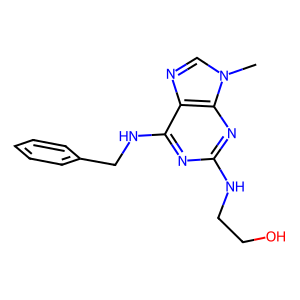

Rank 2: Tanimoto Similarity = 0.1772


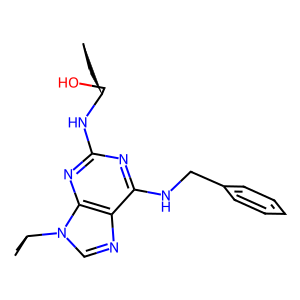

Rank 3: Tanimoto Similarity = 0.1728


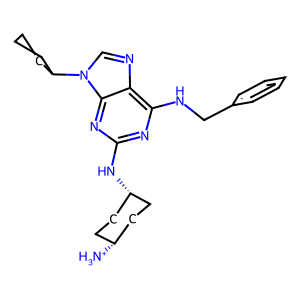

Rank 4: Tanimoto Similarity = 0.1688


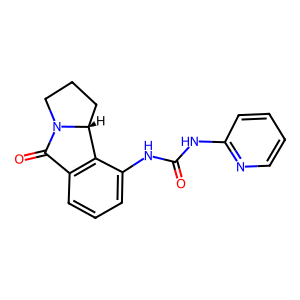

Rank 5: Tanimoto Similarity = 0.1667


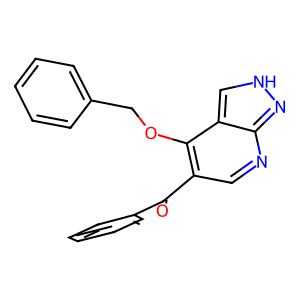

Rank 6: Tanimoto Similarity = 0.1566


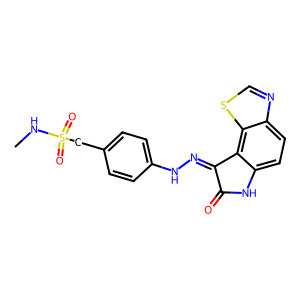

Rank 7: Tanimoto Similarity = 0.1429


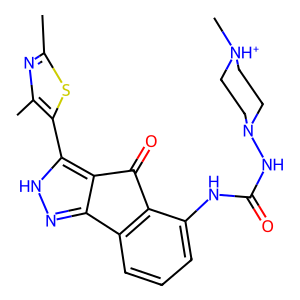

Rank 8: Tanimoto Similarity = 0.1410


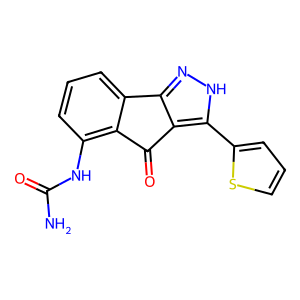

Rank 9: Tanimoto Similarity = 0.1375


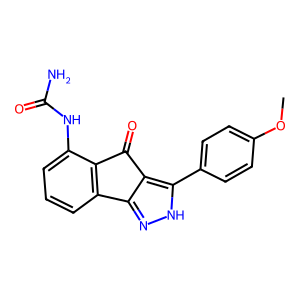

Rank 10: Tanimoto Similarity = 0.1375


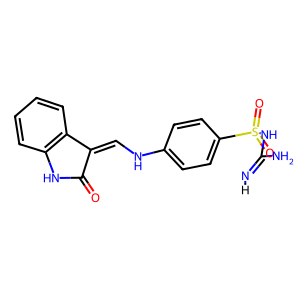

In [22]:
from rdkit import DataStructs

penicillin = Chem.MolFromSmiles("CC1(C(N2C(S1)C(C2=O)NC(=O)CC3=CC=CC=C3)C(=O)O)C")

def read_sdf(file_path):
    suppl = Chem.SDMolSupplier(file_path)
    mols = [mol for mol in suppl if mol is not None]
    return mols

def calc_morgan_fingerprint(mol, radius=2, nBits=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

db_mols = read_sdf('data/cdk2.sdf')
query_fp = calc_morgan_fingerprint(penicillin)
results = []

for mol in db_mols:
    db_fp = calc_morgan_fingerprint(mol)
    sim = DataStructs.TanimotoSimilarity(query_fp, db_fp)
    results.append((mol, sim))

results.sort(key=lambda x: x[1], reverse=True)
top10 = results[:10]
for i, (mol, sim) in enumerate(top10):
    print(f'Rank {i+1}: Tanimoto Similarity = {sim:.4f}')
    display(Draw.MolToImage(mol))

In [26]:
def converter(input_file, output_file):
    sdf_content = read_sdf(input_file)
    with open(output_file, 'w') as f:
        for mol in sdf_content:
            smiles = Chem.MolToSmiles(mol)
            name = mol.GetProp('_Name') if mol.HasProp('_Name') else 'Unknown'
            f.write(smiles + '\t' + name + '\n')

converter('data/cdk2.sdf', 'data/cdk2_smiles.smi')
